# Day 1

## Introduction to Data Science & Machine Learning

Notebook prepared by Nuno R. C. Gomes, IEEC/ICE-CSIC | v20260503

###### Cerdanyola del Vallès, Barcelona, 18-22 May 2026

----

### Environment verification

Let us ensure that the environment is ready for Machine Learning (ML) tasks.
We start by loading relevant packages for our workflow.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
import sys

In [2]:
# print software versions
print(f"Python version: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")

Python version: 3.11.14 (main, Jan 14 2026, 21:09:41) [Clang 21.1.4 ]
NumPy: 2.4.4
Pandas: 3.0.2
Scikit-Learn: 1.8.0


### Key terminology

In ML, we think in terms of _features_, _predictors_, or _independent variables_
$(X)$, and _labels_ or _target variables_ $(y)$.

In [3]:
# DATA
# case/observation (e.g., a patient)
# features: Age, Blood Pressure, BMI
# label: Risk (0: Low, 1: High)
data = {
  'Age': [25, 45, 60, 35, 50],
  'BloodPressure': [110, 140, 150, 120, 135],
  'BMI': [22.5, 28.0, 30.5, 24.1, 27.8],
  'Risk': [0, 1, 1, 0, 1]
}

df0 = pd.DataFrame(data)
print("\nData set overview (observations/cases):")
print(df0)


Data set overview (observations/cases):
   Age  BloodPressure   BMI  Risk
0   25            110  22.5     0
1   45            140  28.0     1
2   60            150  30.5     1
3   35            120  24.1     0
4   50            135  27.8     1


In [4]:
# make copy of original data frame
df = df0.copy()
df

,Age,BloodPressure,BMI,Risk
0,25,110,22.5,0
1,45,140,28.0,1
2,60,150,30.5,1
3,35,120,24.1,0
4,50,135,27.8,1


In [5]:
# separate predictors (X) from the target (y)
X = df.drop('Risk', axis=1) # features
y = df['Risk']              # target

print("\nFeatures (predictors):")
X


Features (predictors):


,Age,BloodPressure,BMI
0,25,110,22.5
1,45,140,28.0
2,60,150,30.5
3,35,120,24.1
4,50,135,27.8


In [6]:
y

0    0
1    1
2    1
3    0
4    1
Name: Risk, dtype: int64

### Model 1: standard linear regression

We now investigate the relationship between a football club's **market value** (independent variable, $x$) and its final **league position** (dependent variable, $y$).
We will fit a simple linear model of the form
$$
y = \beta_0 + \beta_1 x + \varepsilon.
$$

In [9]:
dff = pd.read_csv('data/liga-portugal.csv')
print(f"Data loaded successfully. Dimensions: {dff.shape}")
dff.head(10)

Data loaded successfully. Dimensions: (18, 7)


,Club,Position,Market Value,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Sporting,2,421.56,NaN,NaN,NaN,NaN
1,FC Porto,1,337.81,NaN,NaN,NaN,NaN
2,Benfica,3,323.23,NaN,NaN,NaN,NaN
3,SC Braga,4,156.82,NaN,NaN,NaN,NaN
4,Vitória SC,8,44.52,NaN,NaN,NaN,NaN
5,Famalicão,5,37.21,NaN,NaN,NaN,NaN
6,Santa Clara,12,35.88,NaN,NaN,NaN,NaN
7,Estoril Praia,9,34.84,NaN,NaN,NaN,NaN
8,Rio Ave,13,23.31,NaN,NaN,NaN,NaN
9,Casa Pia,16,21.36,NaN,NaN,NaN,NaN


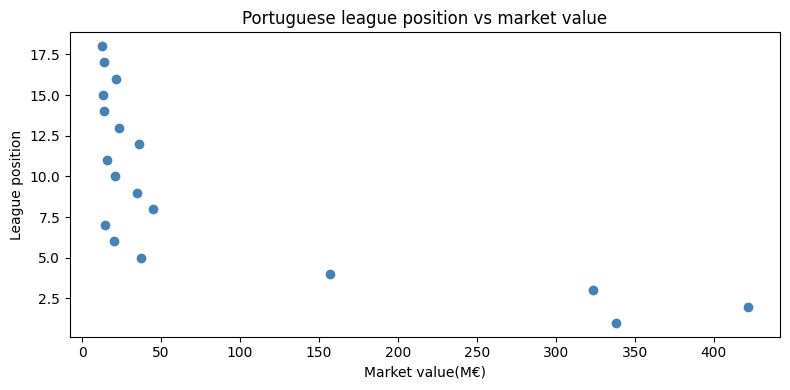

In [10]:
plt.figure(figsize=(8, 4))
plt.scatter(dff['Market Value'], dff['Position'], color='steelblue')
plt.xlabel("Market value(M€)")
plt.ylabel("League position")
plt.title("Portuguese league position vs market value")
plt.tight_layout();

Let us fit a standard linear model to see how well market value directly predicts league standings.

In [11]:
# prepare features and target
X = dff[['Market Value']]
y = dff['Position']

# fit linear regression model
mod1 = LinearRegression()
mod1.fit(X, y)

# extract parameters and compute residuals
slope1 = mod1.coef_[0]
intercept1 = mod1.intercept_
resids1 = y - mod1.predict(X)
rss1 = np.sum(resids1**2)

print(f"Model 1 coefficients")
print("-"*20)
print(f"Slope (beta_1): {slope1: .4f}")
print(f"Intercept (beta_0): {intercept1:.4f}")
print(f"Residual Sum of Squares (RSS): {rss1:.2f}")

Model 1 coefficients
--------------------
Slope (beta_1): -0.0294
Intercept (beta_0): 12.0536
Residual Sum of Squares (RSS): 229.31


#### Results for model 1

- **Slope** ($\beta_1$): $-0.0294$
- **Intercept** ($\beta_0$): $12.0536$
- **RSS**: $229.31$

We plot the data alongside the regression line.
In the second plot, we ensure that the $y$-axis is inverted, so that position 1 is placed at the top.

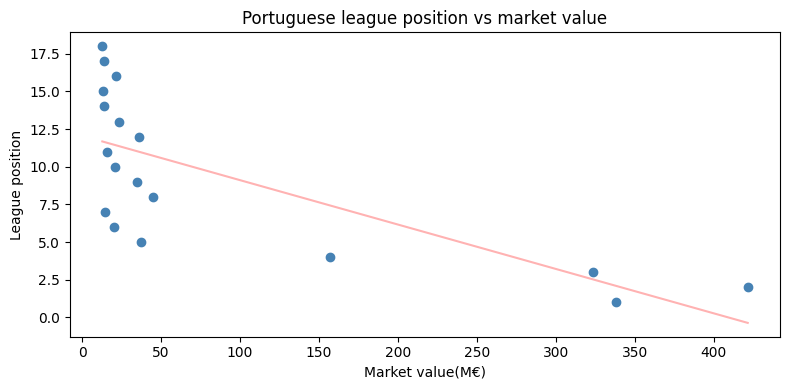

In [12]:
plt.figure(figsize=(8, 4))
plt.scatter(dff['Market Value'], dff['Position'], color='steelblue')
x_range = pd.DataFrame({
  'Market Value': np.linspace(
    dff['Market Value'].min(), dff['Market Value'].max(), 100
  )
})
plt.plot(
  x_range, mod1.predict(x_range), color='red', linestyle='-', alpha=0.3,
  label="Linear trendline"
)
plt.xlabel("Market value(M€)")
plt.ylabel("League position")
plt.title("Portuguese league position vs market value")
plt.tight_layout();

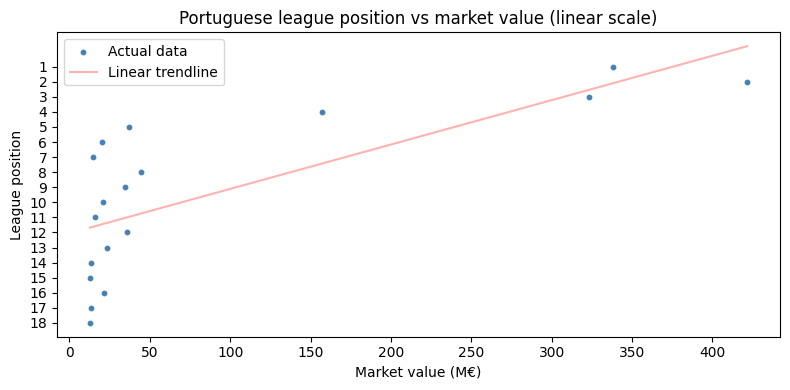

In [13]:
plt.figure(figsize=(8, 4))
plt.clf()
plt.scatter(X, y, color='steelblue', s=10, label="Actual data")
x_range = pd.DataFrame({
  "Market Value": np.linspace(
    dff['Market Value'].min(), dff['Market Value'].max(), 100
  )
})
# x_range = np.linspace(
#   dff['Market Value'].min(), dff['Market Value'].max(), 100
# ).reshape(-1, 1)
plt.plot(
  x_range, mod1.predict(x_range), color='red', linestyle='-', alpha=0.3,
  label="Linear trendline"
)
plt.xlabel("Market value (M€)")
plt.ylabel("League position")
plt.title("Portuguese league position vs market value (linear scale)")
# put position 1 at top
plt.gca().invert_yaxis()
# only integers on y-axis
plt.yticks(sorted(dff['Position'].unique()))
plt.legend()
plt.tight_layout();

### Model 2: log-transformed regression

Economic and market data often exhibit non-linear diminishing returns.
A massive increase in market value at the top end (e.g., from 300M€ to 400M€) might affect league standings less than a smaller change at the lower end (e.g., from 15M€ to 50M€).

Let us transform the feature using $\log_{10}(x)$.

In [15]:
# apply natural logarithm transformation
dff['log10_market_value'] = np.log10(dff['Market Value'])
X_log10 = dff[['log10_market_value']]

# fit new model
mod2 = LinearRegression()
mod2.fit(X_log10, y)

# extract new parameters & compute residuals
slope2 = mod2.coef_[0]
intercept2 = mod2.intercept_
resids2 = y - mod2.predict(X_log10)
rss2 = np.sum(resids2**2)

print(f"Model 2 (log-transformed) coefficients")
print("-"*38)
print(f"Slope (beta_1): {slope2:.4f}")
print(f"Intercept (beta_0): {intercept2:.4f}")
print(f"RSS: {rss2:.2f}")

Model 2 (log-transformed) coefficients
--------------------------------------
Slope (beta_1): -8.2702
Intercept (beta_0): 22.5260
RSS: 166.62


#### Results for model 2

- **Slope** ($\beta_1$): $-8.2702
- **Intercept** ($\beta_0$): $22.5260$
- **RSS**: $166.62$

Notice how the residual sum of squares dropped significantly from $229.31$ to $166.62$.
This indicates that the log-transformed curve captures the underlying structure of the data much more accurately than a straight line.

#### Visualisations

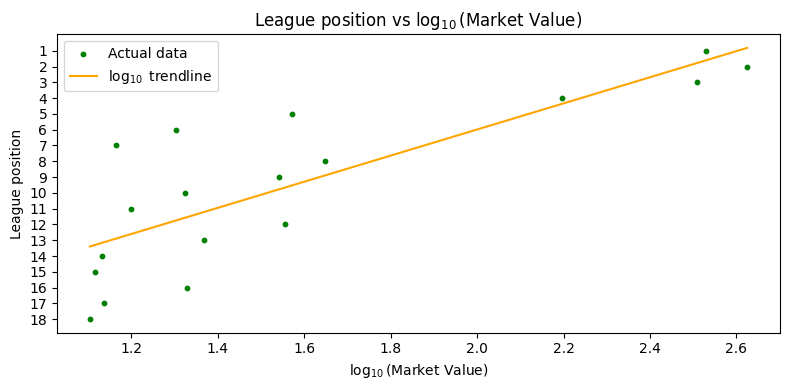

In [17]:
plt.figure(figsize=(8, 4))
plt.clf()
plt.scatter(
  dff['log10_market_value'], dff['Position'],
  s=10, color='green', label='Actual data'
)
x_log10_range = pd.DataFrame({
  "log10_market_value": np.linspace(
    dff['log10_market_value'].min(), dff['log10_market_value'].max(), 100
  )
})
plt.plot(
  x_log10_range, mod2.predict(x_log10_range),
  color='orange', linestyle='-', label=r"$\log_{10}$ trendline"
)
plt.xlabel(r"$\log_{10}(\text{Market Value})$")
plt.ylabel("League position")
plt.title(r"League position vs $\log_{10}(\text{Market Value})$")
plt.gca().invert_yaxis()
plt.yticks(sorted(dff['Position'].unique()))
plt.legend()
plt.tight_layout();

### Predictive comparisons

Let us now see how both models predict league positions for hypothetical clubs with market values ranging from small budget teams $(15\,M€)$ to powerhouse squads $(400\,M€)$.

In [18]:
target_vals = [15, 50, 100, 200, 400, 500]
print("Prediction comparison across models")
print("-"*35)

for val in target_vals:
  # predict using linear model
  X_pred_lin = pd.DataFrame([[val]], columns=["Market Value"])
  pred_lin = mod1.predict(X_pred_lin)[0]
  # predict using log model
  X_pred_log10 = pd.DataFrame(np.log10([[val]]), columns=['log10_market_value'])
  pred_log10 = mod2.predict(X_pred_log10)[0]

  print(
    f"Market value: {val:>3}M€ | "
    f"Linear predicted position: {pred_lin:>5.2f} | "
    f"Logarithmic predicted position: {pred_log10:>5.2f}"
  )

Prediction comparison across models
-----------------------------------
Market value:  15M€ | Linear predicted position: 11.61 | Logarithmic predicted position: 12.80
Market value:  50M€ | Linear predicted position: 10.58 | Logarithmic predicted position:  8.48
Market value: 100M€ | Linear predicted position:  9.11 | Logarithmic predicted position:  5.99
Market value: 200M€ | Linear predicted position:  6.17 | Logarithmic predicted position:  3.50
Market value: 400M€ | Linear predicted position:  0.28 | Logarithmic predicted position:  1.01
Market value: 500M€ | Linear predicted position: -2.67 | Logarithmic predicted position:  0.21


## Visualise overfitting

We are going to create a simple simulation showing a "high variance" (overfit) _vs_ "balanced" model.

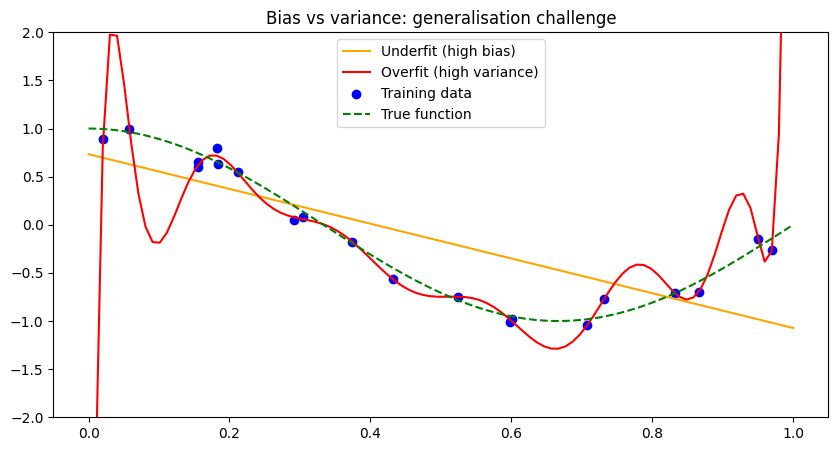

In [19]:
# generate noisy data
np.random.seed(42)
x_plot = np.linspace(0, 1, 100)

def true_fun(X): return np.cos(1.5*np.pi * X)

X_trn = np.sort(np.random.rand(20))
y_trn = true_fun(X_trn) + np.random.randn(20) * 0.1

plt.figure(figsize=(10, 5));

# degree 1 (underfit -> high bias)
model_bias = make_pipeline(
  PolynomialFeatures(1), LinearRegression()
).fit(X_trn[:, np.newaxis], y_trn)

plt.plot(
  x_plot, model_bias.predict(x_plot[:, np.newaxis]),
  label="Underfit (high bias)", color='orange'
)

# Degree 15 (overfit -> high variance)
model_var = make_pipeline(
  PolynomialFeatures(15), LinearRegression()
).fit(X_trn[:, np.newaxis], y_trn)

plt.plot(
  x_plot, model_var.predict(x_plot[:, np.newaxis]),
  label="Overfit (high variance)", color='red'
)

plt.scatter(X_trn, y_trn, label="Training data", color='blue')

plt.plot(
  x_plot, true_fun(x_plot),
  label="True function", linestyle='--', color='green'
)
plt.ylim(-2, 2)
plt.legend()
plt.title("Bias vs variance: generalisation challenge");

---

### References & bibliography

Recommended Reading:
1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning. Springer.
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical Learning. Springer.
3. Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow. O'Reilly.
4. IBM: What is Artificial Intelligence? (https://www.ibm.com/topics/artificial-intelligence)
5. Google Cloud: AI vs ML (https://cloud.google.com/learn/artificial-intelligence-vs-machine-learning)